In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pyshtools as pysh
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
import os 
from meshplot import plot, subplot 
import anndata as ad
import pandas as pd

import igl
from scipy.sparse.linalg import eigsh
from tqdm import tqdm

In [2]:
import utils 
import meshharm

In [3]:
timepoints = ['day1p5', 'day2', 'day2p5', 'day3', 'day3p5', 'day4', 'day4p5', 'day4p5-more']

zarr_names = {
    'day1p5': 'r0.zarr',
    'day2':'r0.zarr',
    'day2p5':'r0.zarr',
    'day3':'r0.zarr',
    'day3p5':'r0.zarr',
    'day4':'r0.zarr',
    'day4p5':'r0.zarr',
    'day4p5-more':'r0.zarr',
}


wells = {
    'day1p5': ['A01', 'A02', 'A03', 'A04', 'A06'],
    'day2': ['A01', 'A02', 'A03', 'A04', 'A05', 'A06'],
    'day2p5': ['A01', 'A02', 'A03', 'A04', 'A05', 'A06'],
    'day3': ['A01', 'A02', 'A03', 'A04', 'A05', 'A06', 'B02', 'B03'],
    'day3p5': ['A01', 'A02', 'A03', 'A04', 'B03'],
    'day4': ['A02', 'A03', 'A04', 'A05', 'A06', 'B01', 'B02'],
    'day4p5': ['A06', 'B06'],
    'day4p5-more': ['C01', 'C02', 'C03', 'C04', 'C06'],
}

rounds = {
    'day1p5': ['0_fused'],
    'day2': ['0_fused'],
    'day2p5': ['0_fused'],
    'day3': ['0_fused'],
    'day3p5': ['0_fused'],
    'day4': ['0_fused'],
    'day4p5': ['0_fused'],
    'day4p5-more': ['0_fused'],
}

meshes = {
    'day1p5': ['nnorg_linked'],
    'day2': ['nnorg_linked'],
    'day2p5': ['nnorg_linked'],
    'day3': ['nnorg_linked'],
    'day3p5': ['nnorg_linked'],
    'day4': ['nnorg_linked'],
    'day4p5': ['nnorgb3'],
    'day4p5-more': ['nnorgb3'],
}

tables = {
    'day1p5':['mesh_features', 'nnorg_linked_expanded1_features'],
    'day2':['mesh_features', 'nnorg_linked_expanded1_features'],
    'day2p5':['mesh_features', 'nnorg_linked_expanded1_features'],
    'day3':['mesh_features', 'nnorg_linked_expanded1_features'],
    'day3p5':['mesh_features', 'nnorg_linked_expanded1_features'],
    'day4':['mesh_features', 'nnorg_linked_expanded1_features'],
    'day4p5':['mesh_features', 'nnorgb3_expanded_features'],
    'day4p5-more':['mesh_features', 'nnorgb3_expanded_features'],
}

times_dic = {
    '1p5': 1.5,
    '2': 2,
    '2p5': 2.5,
    '3': 3,
    '3p5': 3.5,
    '4': 4,
    '4p5': 4.5,
    '4p5-more': 4.5
}

In [4]:
def load(save_path, ts=[0.1, 1, 10]): 
    m = meshharm.MeshHarm()
    m.load_results(save_path)
    frac_diff = m.compute_recon_quality()

    spectrums = []
    for i in range(len(ts)):
        spectrum = m.compute_spectrum(m.coeffs_hks[:, i]) 
        spectrums.append(spectrum) 
    return np.array(spectrums), frac_diff

def plot_explained_variance(pca):

    # Plot explained variance
    _, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # Plot explained variance ratio
    ax1.bar(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_)
    ax1.set_xlabel('Principal Component')
    ax1.set_ylabel('Explained Variance Ratio')
    ax1.set_title('Explained Variance Ratio by Component')
    ax1.grid(True, alpha=0.3)

    # Plot cumulative explained variance
    cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
    ax2.plot(range(0, len(cumulative_variance) + 1), np.concatenate(([0], cumulative_variance,)), 'ko-')
    ax2.set_xlabel('Number of Components')
    ax2.set_ylabel('Cumulative Explained Variance Ratio')
    ax2.set_title('Cumulative Explained Variance')
    ax2.grid(True, alpha=0.3)
    ax2.axhline(y=0.95, color='r', linestyle='--', alpha=0.7, label='95% variance')
    ax2.axhline(y=0.90, color='orange', linestyle='--', alpha=0.7, label='90% variance')
    ax2.set_ylim([0, 1])
    ax2.set_xlim([0, 10])
    ax2.legend()

    plt.tight_layout()
    plt.show()

    # Print some statistics
    print(f"Total explained variance with {len(pca.explained_variance_ratio_)} components: {cumulative_variance[-1]:.4f}")
    print(f"Variance explained by first component: {pca.explained_variance_ratio_[0]:.4f}")
    print(f"Variance explained by second component: {pca.explained_variance_ratio_[1]:.4f}")

In [5]:
spectrums = [] 
times = [] 
fracs = [] 


for timepoint in timepoints:
    zarr_name = zarr_names[timepoint]
    for well_name in wells[timepoint]:
        round_name = rounds[timepoint][0]
        path = f"Data/fractal_output/{timepoint}/{zarr_name}/{well_name[0]}/{well_name[1:]}/{round_name}/"
        labels = np.load(path + 'good_labels.npy').astype('int')
        mesh_name = meshes[timepoint][0]
        mesh_table_name = tables[timepoint][0] 
        print(well_name) 
        for label in tqdm(labels):
            save_path = f"Data/fractal_output/{timepoint}/{zarr_name}/{well_name[0]}/{well_name[1:]}/{round_name}/meshharm_data/{label}"

            mesh_table_path = f"Data/fractal_output/{timepoint}/{zarr_name}/{well_name[0]}/{well_name[1:]}/{round_name}/tables/{mesh_table_name}"

            if os.path.exists(save_path + '_coeffs_v.npy'):
                coor_spectrum, frac = load(save_path)
                spectrums.append(coor_spectrum)
                times.append(timepoint[3:])
                fracs.append(frac)

A01


100%|██████████| 117/117 [00:09<00:00, 12.39it/s]


A02


100%|██████████| 56/56 [00:05<00:00, 10.89it/s]


A03


...

100%|██████████| 142/142 [00:03<00:00, 46.43it/s]


C04


100%|██████████| 107/107 [00:02<00:00, 45.53it/s]


C06


100%|██████████| 150/150 [00:03<00:00, 45.33it/s]


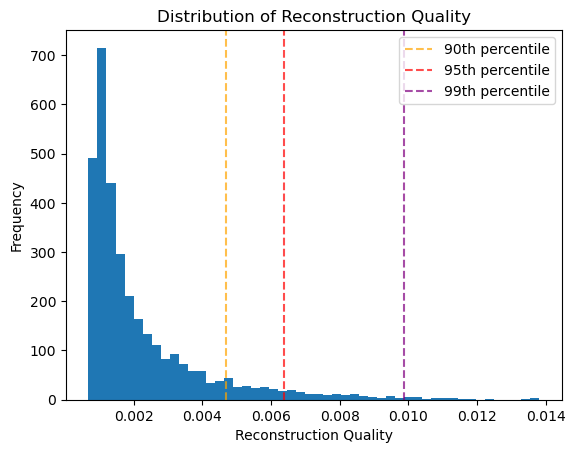

In [7]:
plt.hist(fracs, bins=50)
plt.axvline(np.percentile(fracs, 90), color='orange', linestyle='--', alpha=0.7, label='90th percentile')
plt.axvline(np.percentile(fracs, 95), color='red', linestyle='--', alpha=0.7, label='95th percentile')
plt.axvline(np.percentile(fracs, 99), color='purple', linestyle='--', alpha=0.7, label='99th percentile')
plt.legend()
plt.xlabel('Reconstruction Quality')
plt.ylabel('Frequency')
plt.title('Distribution of Reconstruction Quality')
plt.show()

In [8]:
times_number = [times_dic[time] for time in times]
times_number = np.array(times_number)

In [36]:
threshold = np.percentile(fracs, 95)
mask = np.array(fracs) < threshold

filtered_spectrums = np.array(spectrums)[mask]
filtered_times = np.array(times_number)[mask]

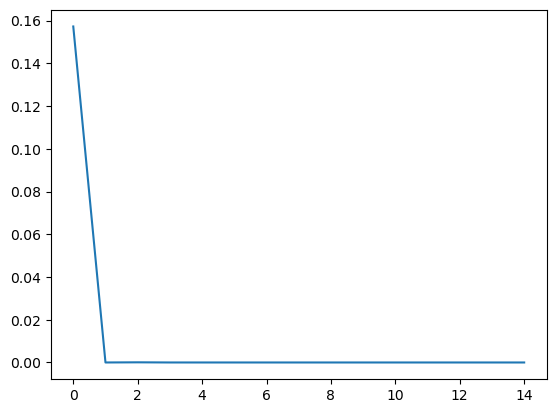

In [37]:
medians = np.median(filtered_spectrums, axis=(0, 1))
plt.plot(medians) 
plt.show() 

In [38]:
spectrums_reshaped = filtered_spectrums.reshape(filtered_spectrums.shape[0], -1)

In [39]:
selector = VarianceThreshold(threshold=1e-10)  # adjust threshold
X_filtered = selector.fit_transform(spectrums_reshaped)
scaler = StandardScaler()
spectrums_reshaped = scaler.fit_transform(X_filtered)


pca = PCA(n_components=10)
res = pca.fit(spectrums_reshaped) 

spectrum_pcs = pca.transform(spectrums_reshaped)

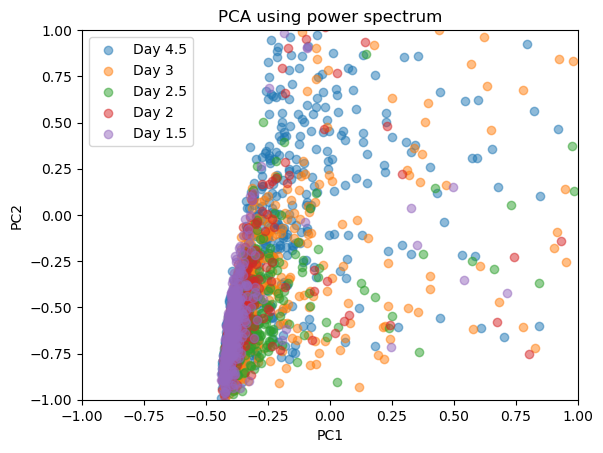

In [40]:
for t in [4.5, 3, 2.5, 2, 1.5]: 
    times_mask = (filtered_times == t)
    plt.scatter(spectrum_pcs[:, 0][times_mask], spectrum_pcs[:, 1][times_mask], alpha=0.5, label=f'Day {t}')
plt.legend() 
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.xlim([-1, 1])
plt.ylim([-1, 1])
plt.title('PCA using power spectrum')
plt.show()

[1.5 2.  2.5 3.  3.5 4.  4.5]


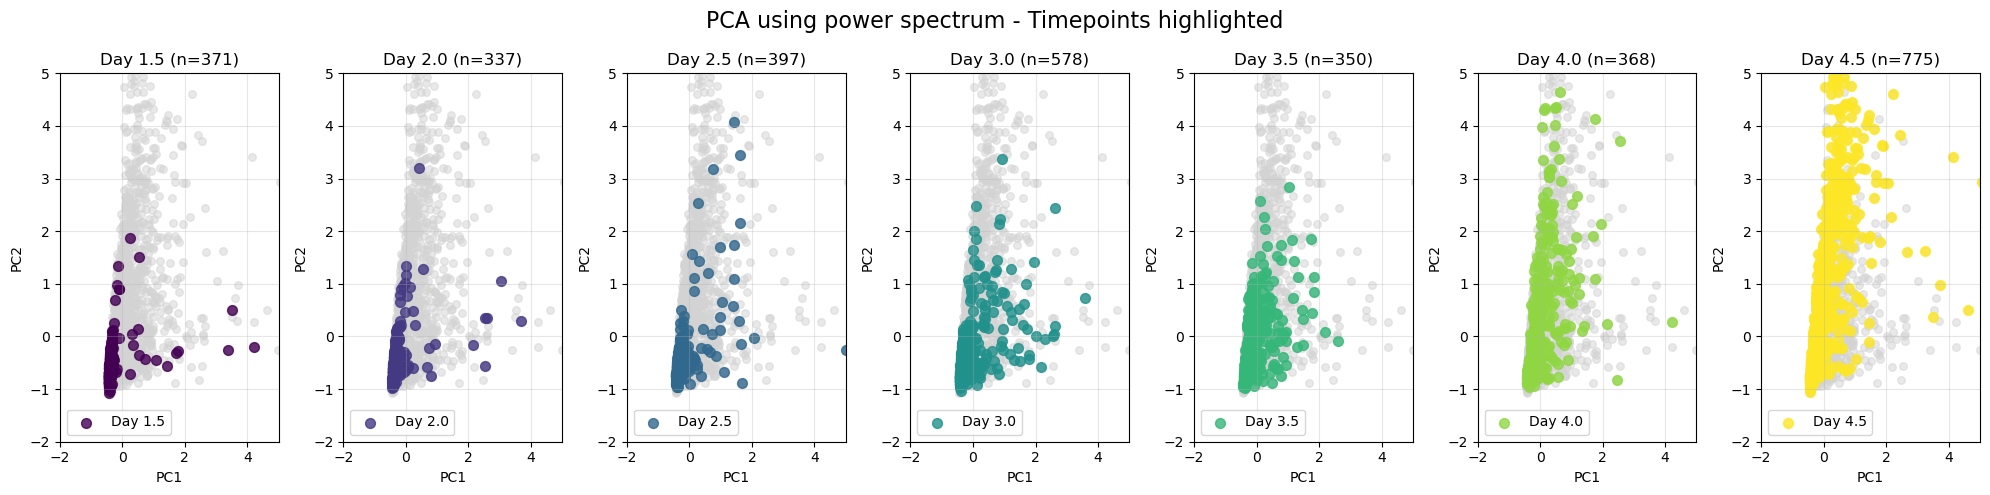

In [43]:
# Create subplots for each timepoint - spectrum PCA
unique_times = np.unique(times_number)

print(unique_times)
# Use a continuous colormap that represents time progression
cmap = plt.cm.viridis  # You can also try 'plasma', 'inferno', 'magma', 'cool', 'warm'
colors = [cmap(i / (len(unique_times) - 1)) for i in range(len(unique_times))]

fig, axes = plt.subplots(1, 7, figsize=(20, 5))

for i, time in enumerate(unique_times):
    ax = axes[i]
    
    # Plot all points in light gray
    ax.scatter(spectrum_pcs[:, 0], spectrum_pcs[:, 1], 
              c='lightgray', alpha=0.5, s=30)
    
    # Highlight current timepoint with color from continuous map
    times_mask = (filtered_times == time)
    ax.scatter(spectrum_pcs[:, 0][times_mask], spectrum_pcs[:, 1][times_mask], 
              c=[colors[i]], alpha=0.8, s=50, label=f'Day {time}')
    
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_ylim([-2, 5])
    ax.set_xlim([-2, 5])
    ax.set_title(f'Day {time} (n={np.sum(times_mask)})')
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.suptitle('PCA using power spectrum - Timepoints highlighted', fontsize=16)
plt.tight_layout()
plt.show()

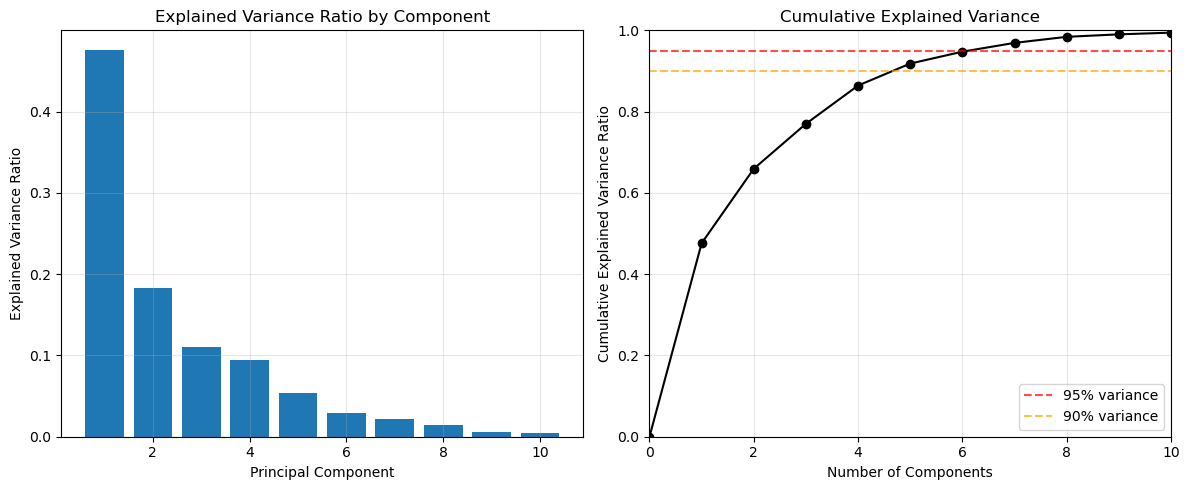

Total explained variance with 10 components: 0.9943
Variance explained by first component: 0.4761
Variance explained by second component: 0.1833


In [44]:
plot_explained_variance(pca)

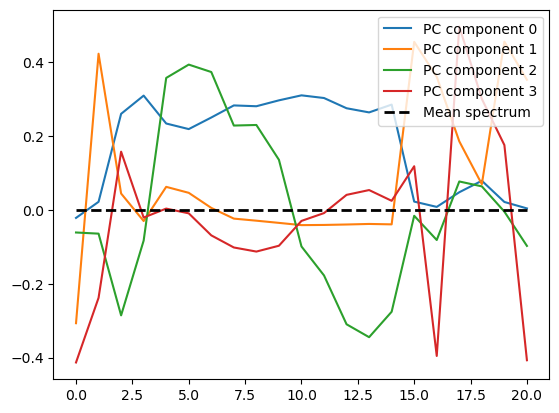

In [45]:
for (i, pc) in enumerate(pca.components_[:4]): 
    plt.plot(pc, '-', label=f'PC component {i}')
plt.plot(pca.mean_, 'k--', label='Mean spectrum', linewidth=2)
plt.legend(loc='upper right') 
plt.show() 